In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

# 加载 Fashion-MNIST 
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

# 转换为合适的类型
X = X.astype(np.float32)
y = y.astype(np.int64)   # 标签转为整数


print(f"数据形状: {X.shape}")  
print(f"标签类别: {np.unique(y)}") 

# 标准化（降维前通常需要）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)





数据形状: (70000, 784)
标签类别: [0 1 2 3 4 5 6 7 8 9]



--- 3.1.2 统计特征分析 ---


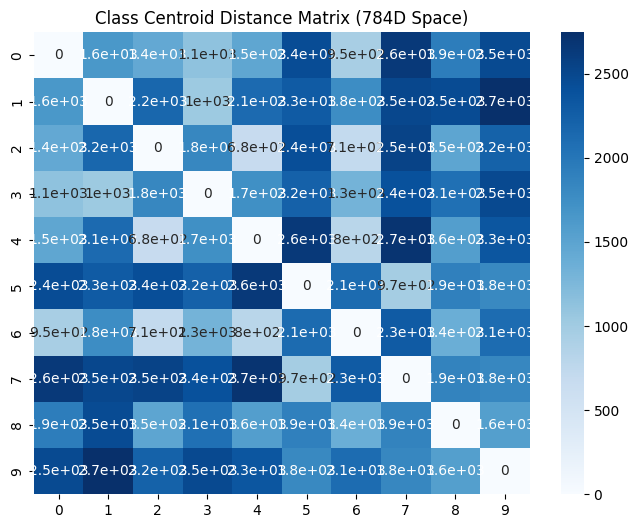

全局均值: 72.5487, 全局方差: 8066.7490


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances
# 随机采样以提升分析效率 
np.random.seed(42)
indices = np.random.choice(len(X), 10000, replace=False)
X_sub, y_sub = X[indices], y[indices]

#3.1.2 节：统计特征与分布特性分析
def analyze_data_properties(X, y):
    print("\n--- 3.1.2 统计特征分析 ---")
    # 计算类中心及距离矩阵
    classes = np.unique(y)
    centroids = np.array([X[y == c].mean(axis=0) for c in classes])
    dist_matrix = euclidean_distances(centroids)
    
    # 绘制距离热力图
    plt.figure(figsize=(8, 6))
    sns.heatmap(dist_matrix, annot=True, cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title("Class Centroid Distance Matrix (784D Space)")
    plt.savefig('class_distance_matrix.png') 
    plt.show()
    
    print(f"全局均值: {X.mean():.4f}, 全局方差: {X.var():.4f}")
    return dist_matrix

dist_matrix = analyze_data_properties(X_sub, y_sub)



In [15]:
#3.2.1 节：标准化与预处理
def preprocess_and_validate(X):
    print("\n--- 3.2.1 标准化预处理 ---")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 验证标准化效果 (均值应趋近于0，方差趋近于1)
    print(f"标准化后 - 均值: {X_scaled.mean():.4f} (应接近0)")
    print(f"标准化后 - 方差: {X_scaled.var():.4f} (应接近1)")
    
    return X_scaled

X_final = preprocess_and_validate(X_sub)
np.save('fashion_mnist_processed.npy', X_final)
print("\n预处理完成，数据已保存。")


--- 3.2.1 标准化预处理 ---
标准化后 - 均值: 0.0000 (应接近0)
标准化后 - 方差: 1.0000 (应接近1)

预处理完成，数据已保存。


原始特征维度: 784
保留 95.0% 方差后的维度: 256


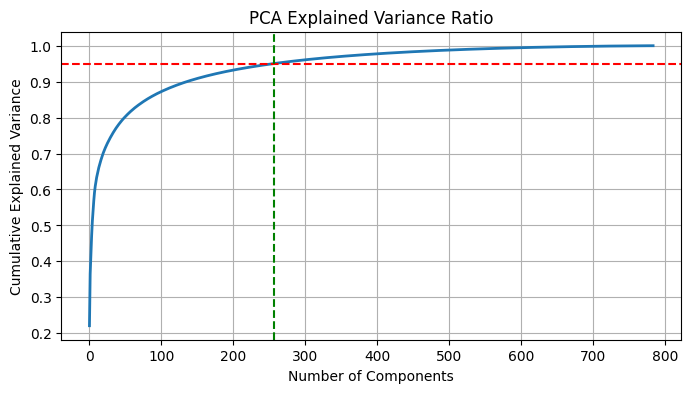

In [ ]:
#3.2.2
from sklearn.decomposition import PCA
def apply_pca_denoising(X_scaled, variance_threshold=0.95):
    """
    对标准化后的数据应用 PCA 降噪
    """
    # 初始化 PCA 模型
    pca = PCA(n_components=variance_threshold)
    X_denoised = pca.fit_transform(X_scaled)
    
    # 获取压缩后的维度
    n_components = pca.n_components_
    print(f"原始特征维度: {X_scaled.shape[1]}")
    print(f"保留 {variance_threshold*100}% 方差后的维度: {n_components}")
    
    # 绘制累积方差贡献率曲线 (用于论文插图)
    pca_all = PCA().fit(X_scaled)
    cumsum = np.cumsum(pca_all.explained_variance_ratio_)
    
    plt.figure(figsize=(8, 4))
    plt.plot(cumsum, linewidth=2)
    plt.axhline(y=variance_threshold, color='r', linestyle='--')
    plt.axvline(x=n_components, color='g', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance Ratio')
    plt.grid(True)
    plt.savefig('pca_variance_plot.png')
    plt.show()
    
    return X_denoised

# 调用函数
X_final = apply_pca_denoising(X_scaled)

In [20]:
!pip install umap-learn

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 404.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ------- -------------------------------- 7.3/41.9 MB 53.8 MB/s eta 0:00:01
   ------- -------------------------------- 7.3/41.9 MB 53.8 MB/s eta 0:00:01
   ------- -------------------------------- 7.3/41.9 MB 53.8 MB/s eta 0:00:01
   ------------- -------------------------- 13.9/41.9 MB 19.4 MB/s eta 0:00:02
   -------------- ------------------------- 15.2/41.9 MB 15.3 MB/s eta 0:00:02
   ----------------- ---------------------- 18.4/41.9 MB 15.5 MB/s eta 0:00:02
   ----------------------- -

In [23]:
import os
os.environ["PYTHONIOENCODING"] = "utf-8"
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding='utf-8')


--- 开始降维对比实验 ---
正在运行 PCA...
PCA 完成: 耗时 0.07s, 轮廓系数 0.398, 同质性 0.410
正在运行 t-SNE...
t-SNE 完成: 耗时 370.46s, 轮廓系数 0.377, 同质性 0.572
正在运行 UMAP...


d:\AAA\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 完成: 耗时 74.85s, 轮廓系数 0.495, 同质性 0.641


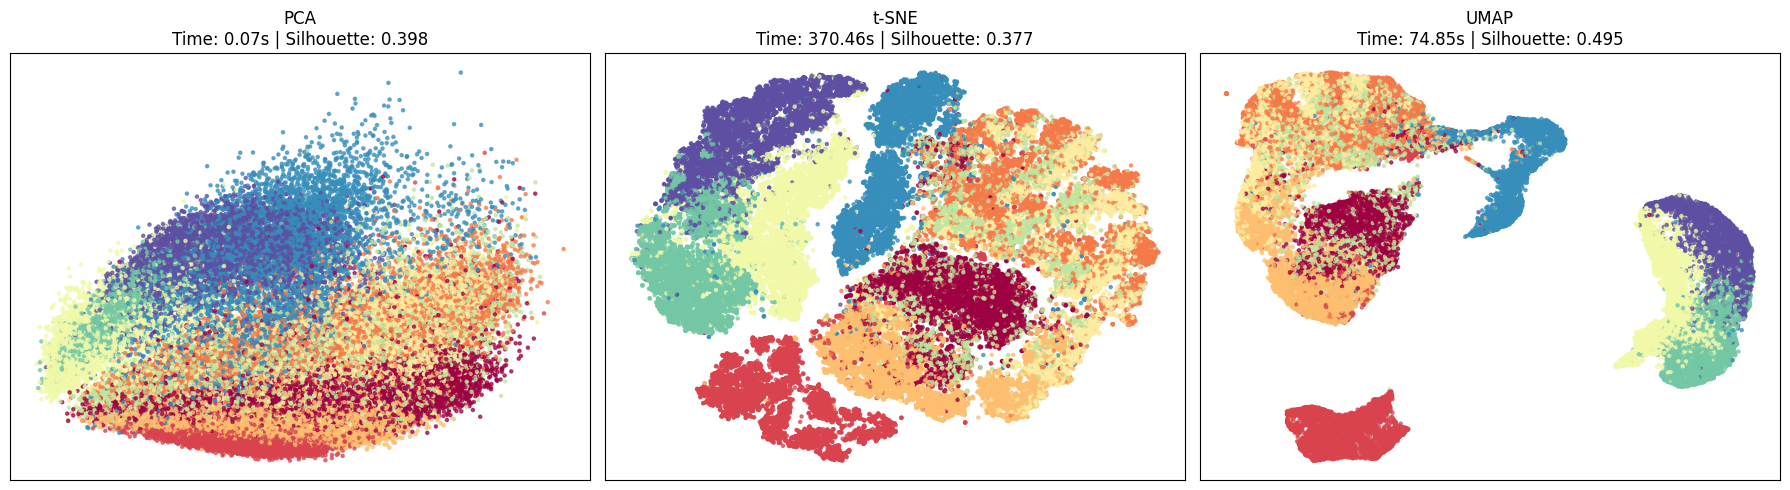


--- 结果汇总 ---
方法         耗时 (s)       轮廓系数         同质性分数
---------------------------------------------
PCA        0.07         0.398        0.410
t-SNE      370.46       0.377        0.572
UMAP       74.85        0.495        0.641


In [24]:
import time
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, homogeneity_score
from sklearn.cluster import KMeans


def run_comparative_experiment(X, y):
    results = {}
    
    algorithms = {
        'PCA': PCA(n_components=2, random_state=42),
        't-SNE': TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30),
        'UMAP': UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    }
    
    print("\n--- 开始降维对比实验 ---")
    for name, model in algorithms.items():
        print(f"正在运行 {name}...")
        start = time.time()
        embedding = model.fit_transform(X)
        duration = time.time() - start
        
        # 用 KMeans 聚类评估降维效果
        cluster_labels = KMeans(n_clusters=10, n_init=10, random_state=42).fit_predict(embedding)
        sil_score = silhouette_score(embedding, cluster_labels)
        homo_score = homogeneity_score(y, cluster_labels)
        
        results[name] = {
            'embedding': embedding,
            'time': duration,
            'silhouette': sil_score,
            'homogeneity': homo_score
        }
        print(f"{name} 完成: 耗时 {duration:.2f}s, 轮廓系数 {sil_score:.3f}, 同质性 {homo_score:.3f}")
    
    return results

# 执行实验
results = run_comparative_experiment(X_final, y)


# 4.1.2 绘制可视化对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ['PCA', 't-SNE', 'UMAP']):
    res = results[name]
    scatter = ax.scatter(res['embedding'][:, 0], res['embedding'][:, 1], 
                         c=y, cmap='Spectral', s=5, alpha=0.7)
    ax.set_title(f"{name}\nTime: {res['time']:.2f}s | Silhouette: {res['silhouette']:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('dimension_reduction_comparison.png', dpi=300)
plt.show()


print("\n--- 结果汇总 ---")
print(f"{'方法':<10} {'耗时 (s)':<12} {'轮廓系数':<12} {'同质性分数'}")
print("-" * 45)
for name, res in results.items():
    print(f"{name:<10} {res['time']:<12.2f} {res['silhouette']:<12.3f} {res['homogeneity']:.3f}")